In [1]:
import pandas as pd
import numpy as np
import cbsyst as cb
import matplotlib.pyplot as plt

In [2]:
dat = pd.read_pickle('latest_run.pkl')

<AxesSubplot:>

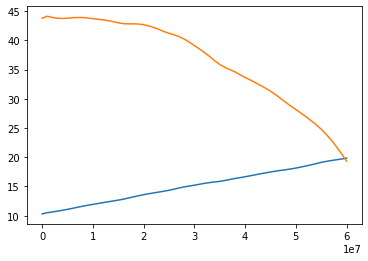

In [3]:
dat.calculated.Ca_ocean_conc.mid.plot()
dat.calculated.Mg_ocean_conc.mid.plot()

In [4]:
cs_modern = cb.Csys(TA=2350, DIC=2050)


In [5]:
Mg_conc = dat.calculated.Mg_ocean_conc.mid * 1e-3
Ca_conc = dat.calculated.Ca_ocean_conc.mid * 1e-3

## Option 1: absolute charge change

In [6]:
dMg_conc = Mg_conc - Mg_conc[0]
dCa_conc = Ca_conc - Ca_conc[0]

dCharge = 2 * dMg_conc + 2 * dCa_conc

<AxesSubplot:>

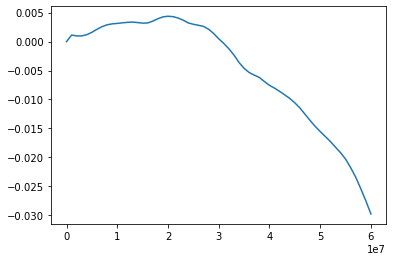

In [7]:
dCharge.plot()

In [36]:
.64 / .7

0.9142857142857144

In [8]:
TA_balance = cs_modern.TA + dCharge * 1e6

<AxesSubplot:>

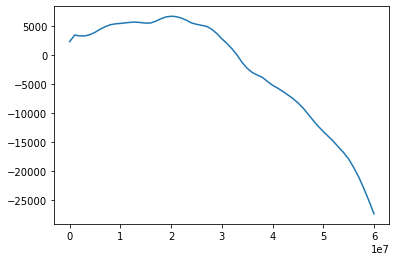

In [9]:
TA_balance.plot()

Doesn't work - TA can't account for deficit. Makes sense, because negative ions also supplied by weathering...

## Option 2: TA changes proportional to relative change in 2+ cation concentration.

Assumes charge imbalance is proportional to weathering input of 2+ cations

In [10]:
doubles = Ca_conc + Mg_conc

r_change = doubles / doubles[0]

<AxesSubplot:>

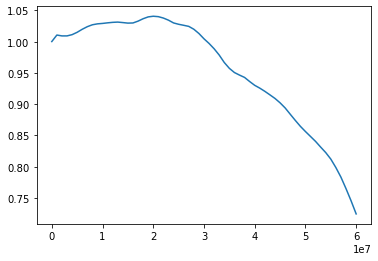

In [11]:
r_change.plot()

In [28]:
TA_balance = cs_modern.TA * r_change
DIC_balance = cs_modern.DIC * r_change**0.5

<AxesSubplot:>

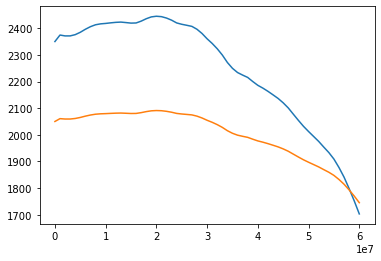

In [29]:
TA_balance.plot()
DIC_balance.plot()

In [30]:
Ks = cb.calc_Ks(T=25, S=35, Ca=Ca_conc, Mg=Mg_conc)
CO3sat = Ks.KspC / Ca_conc
Fsat = 5.1

In [31]:
cCO3 = cb.Csys(TA=TA_balance, CO3=cs_modern.CO3, Ca=Ca_conc, Mg=Mg_conc)
cSat = cb.Csys(TA=TA_balance, CO3=CO3sat * Fsat * 1e6, Ca=Ca_conc, Mg=Mg_conc)
cDIC = cb.Csys(TA=TA_balance, DIC=cs_modern.DIC, Ca=Ca_conc, Mg=Mg_conc)
cScaled = cb.Csys(TA=TA_balance, DIC=DIC_balance, Ca=Ca_conc, Mg=Mg_conc)

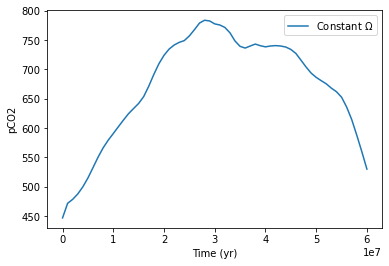

In [34]:
# plt.plot(dat.index, cCO3.pCO2, label='Constant CO3')
plt.plot(dat.index, cSat.pCO2, label='Constant $\Omega$')
# plt.plot(dat.index, cDIC.pCO2, label='Constant DIC')
# plt.plot(dat.index, cScaled.pCO2, label='Scaled DIC')

plt.ylabel('pCO2')
plt.xlabel('Time (yr)')

plt.legend()

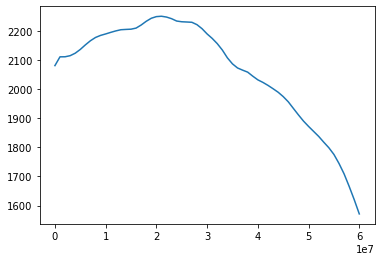

In [27]:
plt.plot(dat.index, cSat.DIC, label='Constant $\Omega$')

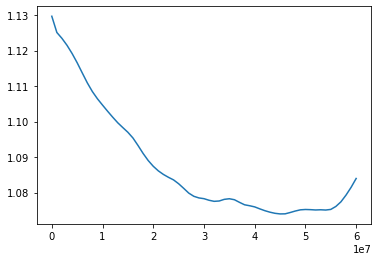

In [35]:
plt.plot(dat.index, cSat.TA / cSat.DIC, label='Constant $\Omega$')